# This script generates a video of general hive visualisation

## Imports

In [1]:
import multiprocessing, cv2, os, sys
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
sys.path.append(os.path.abspath('ABCThermalPlots'))
sys.path.append(os.path.abspath('ABCImaging'))
from libvisu import *
from ABCImaging.libimage import fetchImagesPaths
from ABCImaging.VideoManagment.videolib import initVideoWriter
from InfluxDBInterface.libdb import download_data_DB, removeTmpOutliers
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', 1000)  # Set a wide width for display
pd.set_option('display.colheader_justify', 'center')  # Align column headers
from dask.distributed import Client
# Start a client using all CPUs of this machine
client = Client()
client

A new version of your package is available!
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 22.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 24.4 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 MB 25.0 MB/s  0:00:01m0:00:0100:01
  Attempting uninstall: requests
    Found existing installation: requests 2.32.3
    Uninstalling requests-2.32.3:
      Successfully uninstalled requests-2.32.3
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6
  Attempting uninstall: opencv-python━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/5 [numpy]
    Found existing installation: opencv-python 4.11.0━━━━━━━━━ 1/5 [numpy]
   ━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━ 2/5 [opencv-python]
An error occurred while checking for updates: Command '['/opt/miniconda3/envs/imaging/bin/python', '-m', 'pip', 'install', '--upgrade', 'EasIlastik']' returned non-zero exit stat

error: uninstall-no-record-file

× Cannot uninstall opencv-python 4.11.0
╰─> The package's contents are unknown: no RECORD file was found for opencv-python.

hint: The package was installed by conda. You should check if it can uninstall the package.
INFO:distributed.http.proxy:To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
/opt/miniconda3/envs/imaging/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 53289 instead
  warnings.warn(
INFO:distributed.scheduler:State start
INFO:distributed.diskutils:Found stale lock file and directory '/var/folders/w2/m4mvm5pj37107n10n7fs6sd80000gr/T/dask-scratch-space/scheduler-7yeavgrm', purging
INFO:distributed.diskutils:Found stale lock file and directory '/var/folders/w2/m4mvm5pj37107n10n7fs6sd80000gr/T/dask-scratch-space/worker-snrif1_x', purging
INFO:dist

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:53289/status,
Dashboard: http://127.0.0.1:53289/status,Workers: 4
Total threads: 12,Total memory: 32.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:53290,Workers: 0
Dashboard: http://127.0.0.1:53289/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:53306,Total threads: 3
Dashboard: http://127.0.0.1:53315/status,Memory: 8.00 GiB
Nanny: tcp://127.0.0.1:53293,


## Configuration

In [2]:
# ==== GENERAL SETTINGS ====
hive_nb = 5             # Hive number to process (1 or 2 for OH, 3 for BH and 0 for debugging)
download_data = False    # Set to True to download data from InfluxDB, False to load from local .csv or .dat file
rootpath_imgs = '/Users/cyrilmonette/Library/CloudStorage/SynologyDrive-data/22.12-23.02_actuation_OH/Images/high-fps/subset'     # For images
frame_drop = 1          # We keep 1 frame every frame_drop frames. Put one to keep all frames.
fps = 20                # FPS of the output video

thermal_shift = 'phanomena' # The thermal shift to apply (aSensing3, aSensing3.5, etc.). Use None for no shift
show_co2 = False        # Set to True to show CO2 data on the video
show_htrs = True       # Set to True to show heater data on the video

dest = "outputVideos/phanomena/"

verbose = True          # Set to True to print progress messages

data_path = '/Users/cyrilmonette/Library/CloudStorage/SynologyDrive-data/22.12-23.02_actuation_OH/Thermal meas/' # Path to the local .csv or .dat file containing the CO2, htr and tmp data

## Main code

### Image fetching

In [ ]:
# Get the first and last dt of the video (to know which data to download, and which images to fetch)
all_files = [None] * 4
for i in range(4):
    subfolder = f"h{hive_nb}r{i+1}"
    # list all files in the rootpath_imgs/subfolder
    files = os.listdir(os.path.join(rootpath_imgs, subfolder))
    # sort files by name (which is the timestamp)
    files.sort()
    all_files[i] = files

# find the first and last dt across all subfolders
first_dts = []
last_dts = []
for files in all_files:
    dt_first = pd.to_datetime(files[0].split('.')[0].split('_')[-1], format='%y%m%d-%H%M%S%z')
    dt_last = pd.to_datetime(files[-1].split('.')[0].split('_')[-1], format='%y%m%d-%H%M%S%z')
    first_dts.append(dt_first)
    last_dts.append(dt_last)

first_dt = min(first_dts)
last_dt = max(last_dts)

print(f"First datetime: {first_dt}")
print(f"Last datetime: {last_dt}")

# Get the first datetime rounded to the nearest 5 minutes
first_dt_rounded = first_dt.round('5min')
print(f"First datetime rounded to the nearest 5 minutes: {first_dt_rounded}")

# Get the target dt (for which we need an image, data, etc.)
datetimes = pd.date_range(start=first_dt_rounded, end=last_dt, freq='5min')
datetimes = datetimes[::frame_drop]

# Print the number of dts considered
print(f"Number of datetimes considered: {len(datetimes)}")

imgs_paths = fetchImagesPaths(rootpath_imgs, datetimes, hive_nb, exact_image=False)
print(imgs_paths)
# Count the number of Nones across all rows and all columns
none_count = imgs_paths.isnull().sum().sum()
print(f"Number of missing images: {none_count} out of {len(imgs_paths) * imgs_paths.shape[1]} total images.")

First datetime: 2023-01-09 00:00:01+00:00
Last datetime: 2023-01-09 23:59:59+00:00
First datetime rounded to the nearest 5 minutes: 2023-01-09 00:00:00+00:00
Number of datetimes considered: 288


### tmp fetching

In [ ]:
tmp_csv = [data_path+f"h{hive_nb}r{1}/tmp/abc02_tmp_2023-01-09.csv", data_path+f"h{hive_nb}r{2}/tmp/abc10_tmp_2023-01-09.csv"]
upper = pd.read_csv(tmp_csv[0], header=0)
lower = pd.read_csv(tmp_csv[1], header=0)
# remove the "timestamp" column
upper.drop(columns=['timestamp'], inplace=True)
lower.drop(columns=['timestamp'], inplace=True)
# convert datetime column to pd.to_datetime
upper['datetime'] = pd.to_datetime(upper['datetime'], format='%Y-%m-%dT%H:%M:%S%z')
lower['datetime'] = pd.to_datetime(lower['datetime'], format='%Y-%m-%dT%H:%M:%S%z')

# Remove all duplicates in the datetime column by averaging the values of the other columns for the same datetime
upper = upper.groupby('datetime').mean().reset_index()
lower = lower.groupby('datetime').mean().reset_index()

# Put datetime as index
upper.set_index('datetime', inplace=True)
lower.set_index('datetime', inplace=True)

# make a new df with rows corresponding to the datetimes in the datetimes variable, and extract the rows from upper and lower corresponding to the closest datetime (using the index)
upper = upper.reindex(datetimes, method='nearest')
lower = lower.reindex(datetimes, method='nearest')

print("Upper:")
print(upper.head())
print("Lower:")
print(lower.head())


# Cleaning step of all tmp data: remove outliers
for df in [upper, lower]:
    for col in df.columns:
        df[col] = removeTmpOutliers(df[col], allowed_variation=2.0)

# Restrain both dataframes to the target datetimes
upper = upper[upper.index.isin(datetimes)]
lower = lower[lower.index.isin(datetimes)]
print("After restraining to target datetimes:")
print("Upper hive data shape: ", upper.shape)
print("Lower hive data shape: ", lower.shape)

# Seek the max and min values of the tmp data, in both upper and lower hives
# max_temp = max(upper.max().max(), lower.max().max())
# min_temp = min(upper.min().min(), lower.min().min())

max_temp = np.nanmax([upper.to_numpy(), lower.to_numpy()])
min_temp = np.nanmin([upper.to_numpy(), lower.to_numpy()])
print("Max temperature in the selected time range: ", max_temp)
print("Min temperature in the selected time range: ", min_temp)
print(lower)

Upper:
                              t00        t01        t02        t03        t04        t05        t06        t07        t08        t09        t10        t11        t12        t13        t14        t15        t16        t17        t18        t19        t20        t21        t22        t23        t24        t25        t26        t27        t28        t29        t30        t31        t32        t33        t34        t35        t36        t37        t38        t39        t40        t41        t42        t43        t44        t45        t46        t47        t48        t49        t50        t51        t52        t53        t54        t55        t56        t57        t58        t59        t60        t61        t62        t63   
2023-01-09 00:00:00+00:00  10.679688  10.500000  10.492188  10.609375  10.625000  10.859375  11.796875  11.226562  10.812500  11.054688  10.804688  10.640625  11.898438  12.132812  11.023438  10.757812  11.117188  10.828125  10.867188  11.132812  11.242188  10.97

### Metabolic data fetching

In [ ]:
co2_data = pd.DataFrame()  # Empty DataFrame if CO2 data is not to be shown

### htr fetching

In [ ]:
htr_csv = [data_path+f"h{hive_nb}r{1}/htr/abc02_htr_2023-01-09.csv", data_path+f"h{hive_nb}r{2}/htr/abc10_htr_2023-01-09.csv"]
upper_htr = pd.read_csv(htr_csv[0], header=0)
lower_htr = pd.read_csv(htr_csv[1], header=0)

# Remove the timestamp column
upper_htr.drop(columns=['timestamp'], inplace=True)
lower_htr.drop(columns=['timestamp'], inplace=True)

# Remove all columns that end with "is_active"
upper_htr.drop(columns=[col for col in upper_htr.columns if col.endswith("is_active")], inplace=True)
lower_htr.drop(columns=[col for col in lower_htr.columns if col.endswith("is_active")], inplace=True)
# Remove all columns that end with "status"
upper_htr.drop(columns=[col for col in upper_htr.columns if col.endswith("status")], inplace=True)
lower_htr.drop(columns=[col for col in lower_htr.columns if col.endswith("status")], inplace=True)

# convert datetime column to pd.to_datetime
upper_htr['datetime'] = pd.to_datetime(upper_htr['datetime'], format='%Y-%m-%dT%H:%M:%S%z')
lower_htr['datetime'] = pd.to_datetime(lower_htr['datetime'], format='%Y-%m-%dT%H:%M:%S%z')

# Remove all duplicates in the datetime column by averaging the values of the other columns for the same datetime
upper_htr = upper_htr.groupby('datetime').mean().reset_index()
lower_htr = lower_htr.groupby('datetime').mean().reset_index()

# Put datetime as index
upper_htr.set_index('datetime', inplace=True)
lower_htr.set_index('datetime', inplace=True)

# Rename index to "_time"
upper_htr.index.name = "_time"
lower_htr.index.name = "_time"

# Reindex both dataframes to the datetimes variable, using the nearest method to find the closest datetime
upper_htr = upper_htr.reindex(datetimes, method='nearest')
lower_htr = lower_htr.reindex(datetimes, method='nearest')

upper_htr_new = pd.DataFrame(columns=['_time', '_value', '_field', 'actuator_instance'])
lower_htr_new = pd.DataFrame(columns=['_time', '_value', '_field', 'actuator_instance'])

# From each row, make 10 rows and fill columns called obj, pwm and avg_temp and actuator_instance with the ten values of the original row
for df, df_new in zip([upper_htr, lower_htr], [upper_htr_new, lower_htr_new]):
    for index, row in df.iterrows():
        for i in range(10):
            htr = f"h0{i}"
            # Extract the obj, pwm and avg_temp values for the current actuator instance (f"h0{i}") and fill the new columns with these values
            _obj = row[f"h0{i}_obj"]
            _pwm = row[f"h0{i}_pwm"]
            _avg_temp = row[f"h0{i}_avg_temp"]
            for value, field in zip([_obj, _pwm, _avg_temp], ['obj', 'pwm', 'avg_temp']):
                # Create a new row with _time, _value, _field and actuator_instance columns
                df_new.loc[len(df_new)] = [index, value, field, f"h0{i}"]

upper_htr = upper_htr_new
lower_htr = lower_htr_new

# Convert _time column to index
upper_htr.set_index('_time', inplace=True)
lower_htr.set_index('_time', inplace=True)

# Restrain both dataframes to the target datetimes
upper_htr = upper_htr[upper_htr.index.isin(datetimes)]
lower_htr = lower_htr[lower_htr.index.isin(datetimes)]

print(upper_htr.head())
print(upper_htr.head())

                            _value    _field  actuator_instance
_time                                                          
2023-01-09 00:00:00+00:00   0.00000       obj         h00      
2023-01-09 00:00:00+00:00   0.00000       pwm         h00      
2023-01-09 00:00:00+00:00  11.14063  avg_temp         h00      
2023-01-09 00:00:00+00:00   0.00000       obj         h01      
2023-01-09 00:00:00+00:00   0.00000       pwm         h01      
                            _value    _field  actuator_instance
_time                                                          
2023-01-09 00:00:00+00:00   0.00000       obj         h00      
2023-01-09 00:00:00+00:00   0.00000       pwm         h00      
2023-01-09 00:00:00+00:00  11.14063  avg_temp         h00      
2023-01-09 00:00:00+00:00   0.00000       obj         h01      
2023-01-09 00:00:00+00:00   0.00000       pwm         h01      


### Frame generation

In [ ]:
def generate_frame(dt:pd.Timestamp, contours:list = []):
    """Generate a single annotated frame for the given datetime.

    Args:
        dt (pd.Timestamp): The datetime for which to generate the frame.
    Returns:
        np.ndarray: The generated annotated frame as an image array.
    """

    # Fetch the corresponding image paths
    _imgs_paths = imgs_paths.loc[dt].to_numpy()
    imgs_names = [str(_imgs_paths[j]).split("/")[-1][:-4] for j in range(len(_imgs_paths))]
    # Read the images using cv2
    current_imgs = []
    for _img_path in _imgs_paths:
        if _img_path is not None:
            img = cv2.imread(_img_path, cv2.IMREAD_GRAYSCALE)
            current_imgs.append(img)
        else:
            current_imgs.append(None)
    
    # Thermal data
    try:
        upper_tf = ThermalFrame(upper.loc[dt].to_numpy())
    except (NoValidSensors, KeyError):
        upper_tf = None

    try:
        lower_tf = ThermalFrame(lower.loc[dt].to_numpy())
    except (NoValidSensors, KeyError):
        lower_tf = None

    # Metabolic data
    if dt in co2_data.index:
        metabolic_df = co2_data.loc[dt]
    else:
        metabolic_df = None

    # Lower heater
    if dt in lower_htr.index:
        lower_htr_row = lower_htr.loc[dt]
    else:
        lower_htr_row = None

    # Upper heater
    if dt in upper_htr.index:
        upper_htr_row = upper_htr.loc[dt]
    else:
        upper_htr_row = None
    
    hs = Hive(dt, current_imgs, False, imgs_names, upper_tf, lower_tf, metabolic_df, upper_htr_row, lower_htr_row, hive_nb=hive_nb)
    if thermal_shift is not None:
        from libvisu import thermal_shifts
        hs.setThermalShifts(thermal_shifts[thermal_shift][hive_nb])
    snapshot = hs.snapshot(v_max=max_temp, v_min=min_temp, contours=contours, annotate_contours=True, thermal_transparency=0.4, check_validity=False, annotate_names=False, use_cet_time=True)

    return snapshot

### Plotting

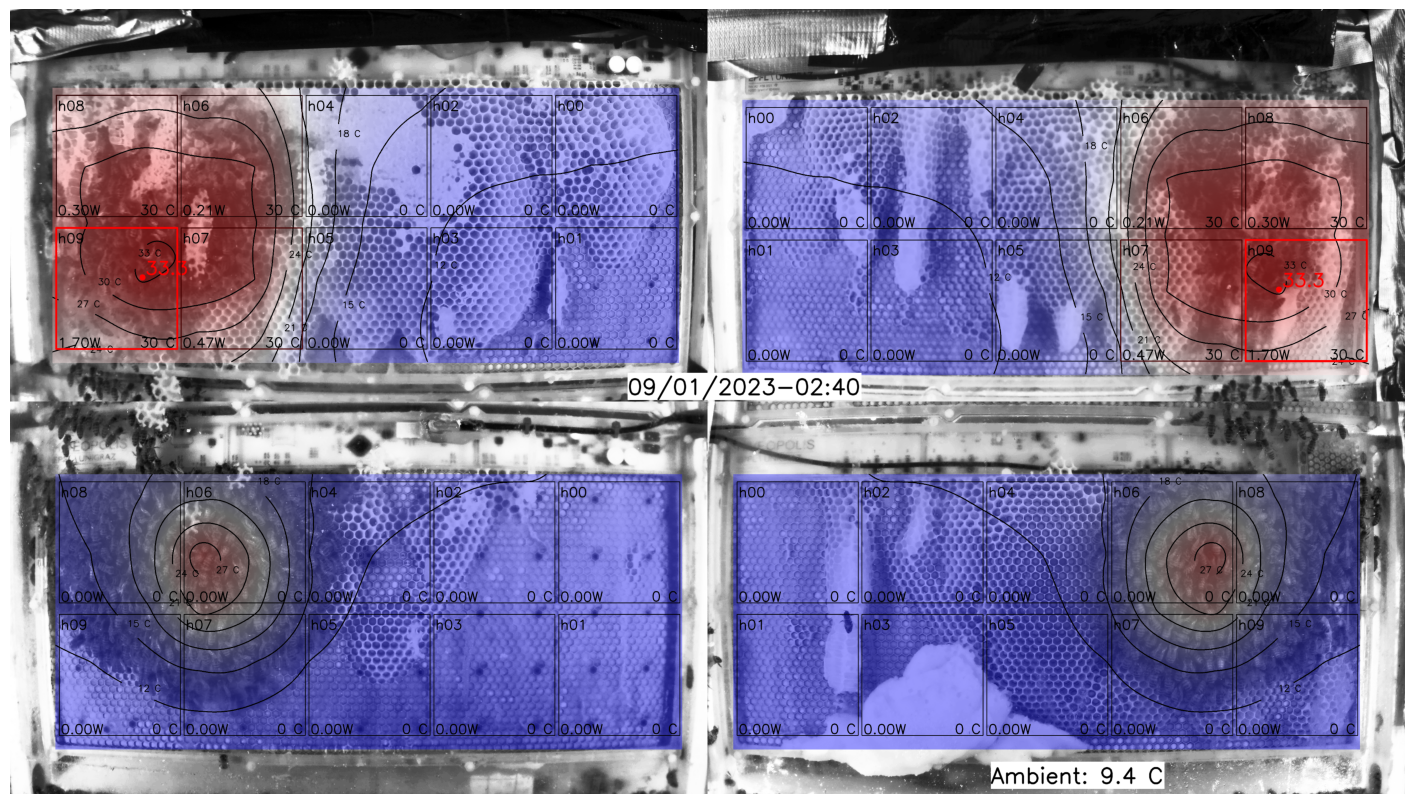

In [ ]:
frame = 20 # Frame idx within datetimes
dt = datetimes[frame]
contours = list(range(12, 37, 3))
snapshot = generate_frame(dt, contours=contours)
# For a random time frame, generate the image of the hive and the thermal plot side by side with matplotlib
# This is just to check that everything is working fine
plt.figure(figsize=(18, 12))
plt.imshow(snapshot)
plt.axis('off') 
plt.show()

### Automation

In [ ]:
snapshot_0 = generate_frame(datetimes[0], contours=contours)
filename=f"hive{hive_nb}_{first_dt.strftime('%y%m%d-%H%M%Z')}_{last_dt.strftime('%y%m%d-%H%M%Z')}"
# If file exists, add a number to the name
counter = 1
while os.path.isfile(dest+filename+".mp4"):
    print(f"File {filename} already exists. Adding a counter to the filename.")
    if counter > 1:
        # Remove the previous counter
        filename = filename[:-(len(str(counter-1))+1)]
    filename = f"{filename}_{counter}"
    counter += 1
    
video = initVideoWriter(dest=dest, shape=snapshot_0.shape, name=filename, fps=fps) # RGB video
print("Writing video with dimensions: ", snapshot_0.shape)

for dt in tqdm(datetimes, desc="Generating video frames"):
    snapshot = generate_frame(dt, contours=contours)
    # Convert from RGB to BGR
    snapshot = cv2.cvtColor(snapshot, cv2.COLOR_RGB2BGR)
    video.write(snapshot)

# Release the VideoWriter object
video.release()
print("Video written successfully.")

# Cleanup step to release resources
multiprocessing.active_children()

File hive5_230109-0000UTC_230109-2359UTC already exists. Adding a counter to the filename.
Writing video with dimensions:  (2160, 3840, 3)


Generating video frames: 100%|██████████| 288/288 [06:12<00:00,  1.29s/it]

Video written successfully.


[<SpawnProcess name='Dask Worker process (from Nanny)' pid=88130 parent=87822 started daemon>,
 <SpawnProcess name='Dask Worker process (from Nanny)' pid=88128 parent=87822 started daemon>,
 <SpawnProcess name='Dask Worker process (from Nanny)' pid=88129 parent=87822 started daemon>,
 <SpawnProcess name='Dask Worker process (from Nanny)' pid=88127 parent=87822 started daemon>]